**Libraries**

In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.linear_model import LogisticRegression #library for defining the algorithm
from sklearn import tree #library for defining the algorithm
from sklearn.tree import DecisionTreeClassifier # library for creating the Decision Tree algorithm
from sklearn.decomposition import PCA #Library for PCA algorithm
from sklearn.preprocessing import LabelEncoder #library for transforming text into numeric
from sklearn.model_selection import train_test_split #library for Splitting train , test data
from sklearn.preprocessing import StandardScaler #Library for Scaling numeric features
from sklearn.metrics import accuracy_score , precision_score, recall_score, f1_score  #library for testing the model quality
import matplotlib.pyplot as plt #library for visualizing graphs
from sklearn.metrics import classification_report #Library for generating reports
import joblib #Library for exporting the model

**Connecting to my drive**

In [5]:
from google.colab import drive
from google.colab import files
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data** **Loading**

In [6]:
df1=pd.read_csv("/content/drive/MyDrive/ai/FINAL/DATA/og_loan_data.csv")
df2=pd.read_csv("/content/drive/MyDrive/ai/FINAL/DATA/11.csv")
print("Numbers of rows in the first dataset:",df1.shape[0])
print("Numbers of rows in the sec dataset:",df2.shape[0])

Numbers of rows in the first dataset: 45000
Numbers of rows in the sec dataset: 367


**Merging Data**

In [7]:
df2_ren = df2.rename(columns={
"Gender": "person_gender",
    "Education": "person_education",
    "ApplicantIncome": "person_income",
    "LoanAmount": "loan_amnt",
})
if "person_gender" in df2_ren.columns:
    df2_ren["person_gender"] = (
        df2_ren["person_gender"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({"m": "male", "male": "male", "f": "female", "female": "female"})
        .astype("object")
    )

if "person_education" in df2_ren.columns:
    df2_ren["person_education"] = (
        df2_ren["person_education"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({"graduate": "graduate", "not graduate": "not_graduate"})
        .astype("object")
    )
#Keeping missing data as it is
for col in ["person_income", "loan_amnt"]:
    if col in df2_ren.columns:
        df2_ren[col] = pd.to_numeric(df2_ren[col], errors="coerce")
#Makeing sure all df1 columns exist in df2_ren
for col in df1.columns:
    if col not in df2_ren.columns:
        df2_ren[col] = np.nan
#identifing extra columns from df2
extra_cols = [c for c in df2_ren.columns if c not in df1.columns]
print("Extra columns kept from df2:", extra_cols)
#Merging data
df_merged = pd.concat([df1, df2_ren], ignore_index=True, sort=False)

Extra columns kept from df2: ['Loan_ID', 'Married', 'Dependents', 'Self_Employed', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


**Downlowding merged data before cleaning**

In [8]:
df_merged.to_csv("/content/drive/MyDrive/ai/dirty_data.csv", index=False)
print("The DIRTY dataset has been saved successfully")

The DIRTY dataset has been saved successfully


**Data Reading**

In [9]:
df_merged.info()
print(df_merged.head())
print("Numbers of columns:",df_merged.shape[1] , ", Numbers of rows:",df_merged.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45367 entries, 0 to 45366
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45356 non-null  object 
 2   person_education                45367 non-null  object 
 3   person_income                   45367 non-null  float64
 4   person_emp_exp                  45000 non-null  float64
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45362 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  float64
 12  previous_loan_defaults_on_file  

**Data Cleaning:**

**Dropping Unwanted Columns**

In [10]:
df_merged.drop(["loan_int_rate"], axis=1, inplace=True)
print("remaining columns:")
df_merged.head()

remaining columns:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_percent_income,cb_person_cred_hist_length,...,previous_loan_defaults_on_file,loan_status,Loan_ID,Married,Dependents,Self_Employed,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
0,22.0,female,Master,71948.0,0.0,RENT,35000.0,PERSONAL,0.49,3.0,...,No,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21.0,female,High School,12282.0,0.0,OWN,1000.0,EDUCATION,0.08,2.0,...,Yes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25.0,female,High School,12438.0,3.0,MORTGAGE,5500.0,MEDICAL,0.44,3.0,...,No,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,23.0,female,Bachelor,79753.0,0.0,RENT,35000.0,MEDICAL,0.44,2.0,...,No,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24.0,male,Master,66135.0,1.0,RENT,35000.0,MEDICAL,0.53,4.0,...,No,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Checking for dublicated rows**

In [11]:
print("is there any dublicated rows?",df_merged.duplicated().any())
print("number of duplicated rows:", df_merged.duplicated().sum())

is there any dublicated rows? False
number of duplicated rows: 0


**detacting missing values in the data**

In [12]:
print("number of missing values in the data:",df_merged.isnull().sum().sum())
print("the percentage of the missing values in each column:\n",df_merged.isnull().mean()) #the precentage of the missing values
null_counts = df_merged.isnull().sum()
null_columns = null_counts[null_counts > 0]
print("the columns that have missing data and how many cells missing:\n",null_columns)

number of missing values in the data: 363387
the percentage of the missing values in each column:
 person_age                        0.008090
person_gender                     0.000242
person_education                  0.000000
person_income                     0.000000
person_emp_exp                    0.008090
person_home_ownership             0.008090
loan_amnt                         0.000110
loan_intent                       0.008090
loan_percent_income               0.008090
cb_person_cred_hist_length        0.008090
credit_score                      0.008090
previous_loan_defaults_on_file    0.008090
loan_status                       0.008090
Loan_ID                           0.991910
Married                           0.991910
Dependents                        0.992131
Self_Employed                     0.992417
CoapplicantIncome                 0.991910
Loan_Amount_Term                  0.992043
Credit_History                    0.992550
Property_Area                     0.99191

**Dropping columns with full missing values (99% missing)**

In [13]:
df_merged.drop(["Loan_ID",
    "Married",
    "Dependents",
    "Self_Employed",
    "CoapplicantIncome",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area"
    ], axis=1, inplace=True)
print("remaining columns:")
df_merged.head()

remaining columns:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0.0,RENT,35000.0,PERSONAL,0.49,3.0,561.0,No,1.0
1,21.0,female,High School,12282.0,0.0,OWN,1000.0,EDUCATION,0.08,2.0,504.0,Yes,0.0
2,25.0,female,High School,12438.0,3.0,MORTGAGE,5500.0,MEDICAL,0.44,3.0,635.0,No,1.0
3,23.0,female,Bachelor,79753.0,0.0,RENT,35000.0,MEDICAL,0.44,2.0,675.0,No,1.0
4,24.0,male,Master,66135.0,1.0,RENT,35000.0,MEDICAL,0.53,4.0,586.0,No,1.0


**filling missing values using mode and median**

In [14]:
print("Missing values before filling:")
print(df_merged.isnull().sum())
# Fill categorical columns using MODE
mode_cols = ["person_gender", "person_education",
             "person_home_ownership","loan_intent",
             "previous_loan_defaults_on_file"]
for col in mode_cols:
    mode_value = df_merged[col].mode()[0]
    df_merged[col] = df_merged[col].fillna(mode_value)
# Fill numeric columns using MEDIAN
median_cols = ["person_age", "person_income",
               "person_emp_exp","loan_amnt","loan_percent_income",
               "cb_person_cred_hist_length",
               "credit_score","loan_status"]
for col in median_cols:
    median_value = df_merged[col].median()
    df_merged[col] = df_merged[col].fillna(median_value)
print("Missing values after filling:")
print(df_merged.isnull().sum())


Missing values before filling:
person_age                        367
person_gender                      11
person_education                    0
person_income                       0
person_emp_exp                    367
person_home_ownership             367
loan_amnt                           5
loan_intent                       367
loan_percent_income               367
cb_person_cred_hist_length        367
credit_score                      367
previous_loan_defaults_on_file    367
loan_status                       367
dtype: int64
Missing values after filling:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0


**Converting data from text to number**

In [15]:
le = LabelEncoder()
#Determining text columns to convert
df_merged["person_gender"] = le.fit_transform(df_merged["person_gender"].astype(str))
df_merged["person_education"] = le.fit_transform(df_merged["person_education"].astype(str))
df_merged["person_home_ownership"] = le.fit_transform(df_merged["person_home_ownership"].astype(str))
df_merged["loan_intent"] = le.fit_transform(df_merged["loan_intent"].astype(str))
df_merged["previous_loan_defaults_on_file"] = le.fit_transform(df_merged["previous_loan_defaults_on_file"].astype(str))
#printing columns after encoding
cols_to_show = ["person_education",
                "person_home_ownership",
                "loan_intent",
                "previous_loan_defaults_on_file"]

df_merged[cols_to_show].head()


,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,4,3,4,0
1,3,2,1,1
2,3,0,3,0
3,1,3,3,0
4,4,3,3,0


**discovering the outliers**

In [16]:
print("discovering the outliers\n",df_merged.describe())
q3_income = df_merged["person_income"].quantile(0.75)
outliers = (
    (df_merged["person_age"] > 100) |
    (df_merged["person_emp_exp"] > 60) |
    (df_merged["person_income"] > 3 * q3_income)
)
print("number of outliers columns\n", outliers.sum())
print("the percentage of outliers of the data\n", float(outliers.mean()) * 100)
outliers_preview = df_merged.loc[outliers].head()
print(outliers_preview)

discovering the outliers
          person_age  person_gender  person_education  person_income  \
count  45367.000000   45367.000000      45367.000000   4.536700e+04   
mean      27.749906       0.554103          1.772125   7.970818e+04   
std        6.022681       0.497070          1.506340   8.038288e+04   
min       20.000000       0.000000          0.000000   0.000000e+00   
25%       24.000000       0.000000          0.000000   4.670000e+04   
50%       26.000000       1.000000          1.000000   6.692600e+04   
75%       30.000000       1.000000          3.000000   9.514100e+04   
max      144.000000       1.000000          6.000000   7.200766e+06   

       person_emp_exp  person_home_ownership     loan_amnt   loan_intent  \
count    45367.000000           45367.000000  45367.000000  45367.000000   
mean         5.398924               1.707166   9507.601781      2.513567   
std          6.040277               1.439401   6345.229249      1.726719   
min          0.000000         

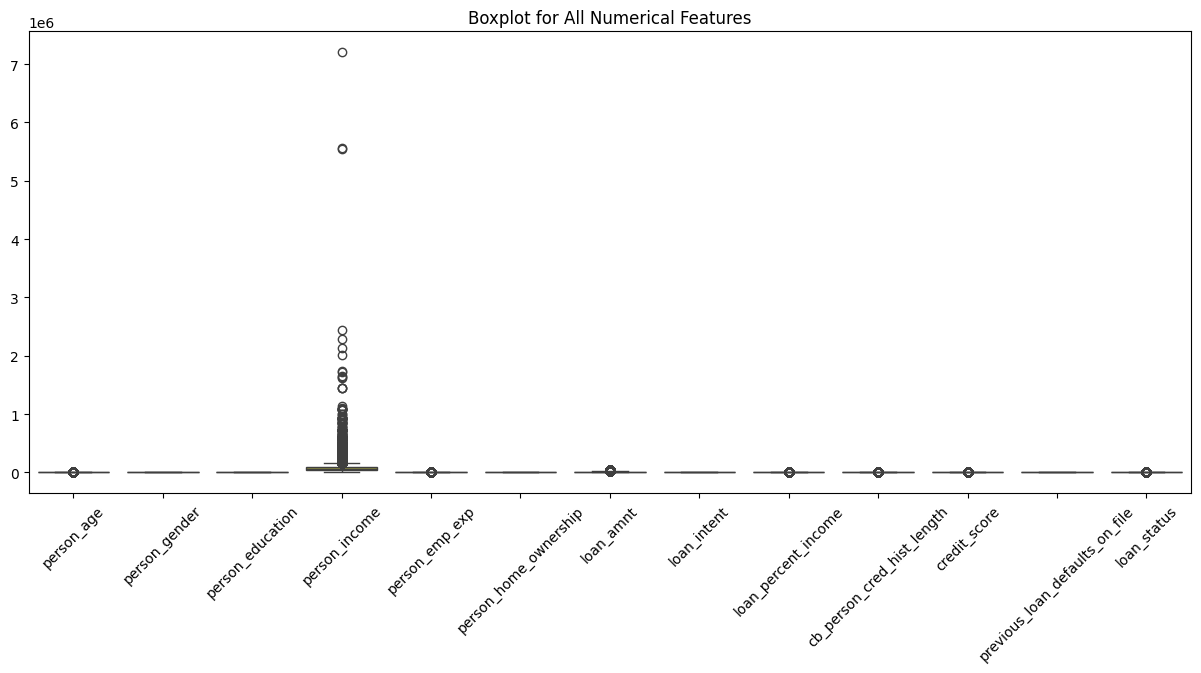

In [17]:
import seaborn as sns
num_cols = df_merged.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_merged[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for All Numerical Features")
plt.show()

**dropping outliers values**

In [18]:
df= df_merged.loc[~outliers].copy()
print("number of rows before dropping", len(df_merged))
print("number of rows after dropping", len(df))

number of rows before dropping 45367
number of rows after dropping 44958


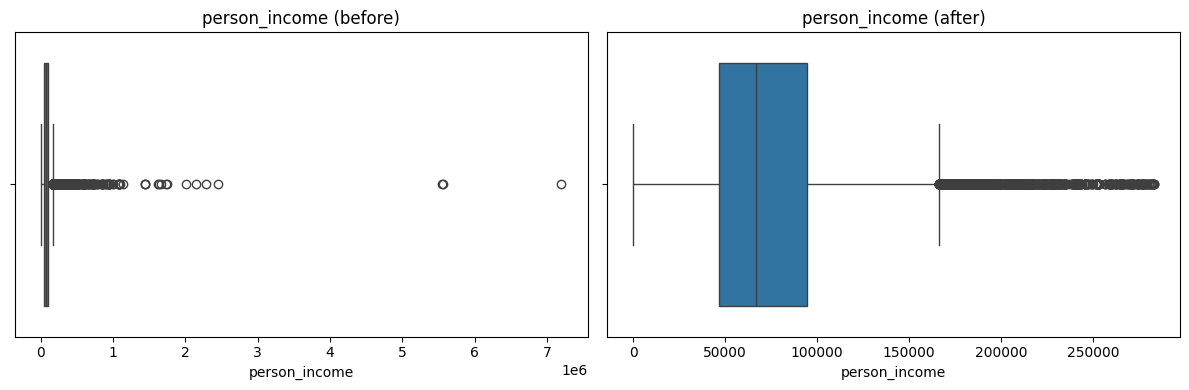

In [19]:
import seaborn as sns
col = "person_income"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_merged[col], ax=axes[0])
axes[0].set_title(col + " (before)")
sns.boxplot(x=df[col], ax=axes[1])
axes[1].set_title(col + " (after)")
plt.tight_layout()
plt.show()

**Downlowding data after cleaning file**

In [20]:
df.to_csv("/content/drive/MyDrive/ai/clean_data.csv", index=False)
print("The CLEAN dataset has been saved successfully")

The CLEAN dataset has been saved successfully


**Determining X,Y**

In [21]:
print(df.columns) #to see the whole columns and extract it
features=['person_age','person_gender' , 'person_education', 'person_income', 'person_emp_exp',
       'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file']
x=df[features] #x:all the columns exept the target
y=df['loan_status'] #y:the targeted column for prediction
print(x,y) #to make sure the whole columns are right
x.shape
y.shape

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')
       person_age  person_gender  person_education  person_income  \
0            22.0              0                 4        71948.0   
1            21.0              0                 3        12282.0   
2            25.0              0                 3        12438.0   
3            23.0              0                 1        79753.0   
4            24.0              1                 4        66135.0   
...           ...            ...               ...            ...   
45362        26.0              1                 6         4009.0   
45363        26.0              1                 5         4158.0   
45364        26.0              1                 5         3250.0   
45

(44958,)

**Splitting train , test data**

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=20)
print("train data",x_train) #to make sure the whole train columns are right
print("test data",x_test) #to make sure the whole test columns are right
x_train.shape
x_test.shape
y_train.shape
y_test.shape

train data        person_age  person_gender  person_education  person_income  \
4353         21.0              1                 1        20273.0   
25508        34.0              1                 2        91089.0   
16057        25.0              1                 3       151111.0   
5790         26.0              1                 0        19878.0   
34440        26.0              1                 3        44341.0   
...           ...            ...               ...            ...   
32247        36.0              1                 0       163068.0   
23577        30.0              1                 1        40292.0   
23900        28.0              1                 1        30051.0   
37484        24.0              1                 3        58396.0   
27224        35.0              0                 0       153006.0   

       person_emp_exp  person_home_ownership  loan_amnt  loan_intent  \
4353              0.0                      3     4800.0            3   
25508           

(8992,)

**Checking for bias in the data**

In [23]:
# counting the percentage of male,female in the gender column
gender_counts = x_train["person_gender"].value_counts(normalize=True) * 100
print("Percentage of males   : ", gender_counts.get(1, 0))
print("Percentage of females : ", gender_counts.get(0, 0))

Percentage of males   :  55.35505755435689
Percentage of females :  44.64494244564311


**Scaling Features**

In [24]:
#Selecting only numerical columns
num_cols = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Initializing the scaler
scaler = StandardScaler()
#fitting only train data
scaler.fit(x_train[num_cols])
#copy to keep DataFrame
x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()
#forcing numeric columns to be float
x_train_scaled.loc[:, num_cols] = x_train_scaled[num_cols].astype("float64")
x_test_scaled.loc[:,  num_cols] = x_test_scaled[num_cols].astype("float64")
# transform only the numeric columns
x_train_scaled.loc[:, num_cols] = scaler.transform(x_train[num_cols])
x_test_scaled.loc[:, num_cols]  = scaler.transform(x_test[num_cols])
print("Scaling completed successfully for numeric columns")
print("First 5 rows before scaling:")
display(x_train.head())
print("First 5 rows after scaling:")
display(x_train_scaled.head())

Scaling completed successfully for numeric columns
First 5 rows before scaling:


/tmp/ipython-input-1867099563.py:14: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.8980644   0.8980644   0.8980644  ...  0.8980644   0.8980644
 -1.11350589]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipython-input-1867099563.py:14: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.5162228   0.14805159  0.81232597 ... -0.5162228   0.81232597
 -1.18049718]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipython-input-1867099563.py:14: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.89286333  0.89286333 -1.192875   ...  0.89286333 -1.192875
 -1.192875  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipython-input-1867099563.p

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
4353,21.0,1,1,20273.0,0.0,3,4800.0,3,0.24,3.0,639.0,0
25508,34.0,1,2,91089.0,10.0,3,12000.0,5,0.13,8.0,574.0,1
16057,25.0,1,3,151111.0,2.0,0,12000.0,1,0.08,3.0,643.0,0
5790,26.0,1,0,19878.0,0.0,3,5500.0,0,0.28,3.0,676.0,0
34440,26.0,1,3,44341.0,3.0,3,7000.0,4,0.16,6.0,645.0,0


First 5 rows after scaling:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
4353,-1.144980,0.898064,-0.516223,-1.317114,-0.911435,0.892863,-0.739196,0.283670,1.147191,-0.734182,0.124449,-1.021189
25508,1.087399,0.898064,0.148052,0.367104,0.800483,0.892863,0.408251,1.440020,-0.121158,0.571410,-1.172897,0.979251
16057,-0.458094,0.898064,0.812326,1.794608,-0.569051,-1.192875,0.408251,-0.872680,-0.697681,-0.734182,0.204285,-1.021189
5790,-0.286373,0.898064,-1.180497,-1.326509,-0.911435,0.892863,-0.627639,-1.450855,1.608408,-0.734182,0.862938,-1.021189
34440,-0.286373,0.898064,0.812326,-0.744705,-0.397859,0.892863,-0.388587,0.861845,0.224755,0.049173,0.244204,-1.021189


**Decision tree Algorithm**

In [25]:
# Initializing the Decision Tree Algorithm
dtree = DecisionTreeClassifier(random_state=52)
# Training the model
dtree.fit(x_train_scaled, y_train)
# classifeing the values
y_pred = dtree.predict(x_test_scaled)

**Logistic Regression Algorithm**

In [26]:
logistic_model = LogisticRegression() # Initializing the Algorithm
logistic_model.fit(x_train_scaled, y_train) #training the data
y_pred_lr=logistic_model.predict(x_test_scaled) #classifeing the values

**Testing the model with a new value**

In [27]:
# defining a new sample with encoded values
person_age_test = 30
person_gender_test = 1
person_education_test = 2
person_income_test = 50000
person_emp_exp_test = 5
person_home_ownership_test = 1
loan_amnt_test = 10000
loan_intent_test = 3
loan_percent_income_test = 0.2
cb_person_cred_hist_length_test = 5
credit_score_test = 700
previous_loan_defaults_on_file_test = 0

# Making sure the input array is in the same order used during training
x_test_scaled = [[
    person_age_test,
    person_gender_test,
    person_education_test,
    person_income_test,
    person_emp_exp_test,
    person_home_ownership_test,
    loan_amnt_test,
    loan_intent_test,
    loan_percent_income_test,
    cb_person_cred_hist_length_test,
    credit_score_test,
    previous_loan_defaults_on_file_test
]]
# predicting the new value
test_y = dtree.predict(x_test_scaled)
# printing the result
print("Test Input = ", x_test_scaled)
label = "approved" if test_y == 1 else "rejected"
print("Predicted Loan Status = ", label)

Test Input =  [[30, 1, 2, 50000, 5, 1, 10000, 3, 0.2, 5, 700, 0]]
Predicted Loan Status =  rejected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names



**testing the decision tree model's quality**

In [28]:
# Calculating the accuracy of the prediction in the model
print("Calculating model's quality:\n")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)
# Calculating the Precision of the predicted positives (approved loans) in the model
precision = precision_score(y_test, y_pred, average="binary", zero_division=0)
print("Precision =", precision)
# Calculating the Recall of the predicted positives (approved loans) in the model
recall = recall_score(y_test, y_pred, average="binary", zero_division=0)
print("Recall =", recall)
# Calculating F1
f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)
print("F1 Score =", f1)
#showing the model's quality in percent format:
print("Calculating model's quality in percentage:\n")
print("Accuracy:", accuracy * 100, "%")
print("Precision:", precision * 100, "%")
print("Recall:", recall * 100, "%")
print("F1 Score:", f1 * 100, "%")

Calculating model's quality:

Accuracy = 0.8677713523131673
Precision = 0.6943187531422825
Recall = 0.7038735983690112
F1 Score = 0.6990635282207036
Calculating model's quality in percentage:

Accuracy: 86.77713523131672 %
Precision: 69.43187531422825 %
Recall: 70.38735983690113 %
F1 Score: 69.90635282207036 %


**testing the Logistic Regression model's quality**

In [29]:
# Calculating the accuracy of the prediction in the model
print("Calculating model's quality:\n")
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy =", accuracy_lr)
# Calculating the Precision of the predicted positives (approved loans) in the model
precision_lr = precision_score(y_test, y_pred_lr, average="binary", zero_division=0)
print("Precision =", precision_lr)
# Calculating the Recall of the predicted positives (approved loans) in the model
recall_lr = recall_score(y_test, y_pred_lr, average="binary", zero_division=0)
print("Recall =", recall_lr)
# Calculating F1
f1_lr = f1_score(y_test, y_pred_lr, average="binary", zero_division=0)
print("F1 Score =", f1_lr)
#showing the model's quality in percent format:
print("Calculating model's quality in percentage:\n")
print("Accuracy:", accuracy * 100, "%")
print("Precision:", precision * 100, "%")
print("Recall:", recall * 100, "%")
print("F1 Score:", f1 * 100, "%")

Calculating model's quality:

Accuracy = 0.8658807829181495
Precision = 0.7184971098265895
Recall = 0.6335372069317023
F1 Score = 0.6733477789815818
Calculating model's quality in percentage:

Accuracy: 86.77713523131672 %
Precision: 69.43187531422825 %
Recall: 70.38735983690113 %
F1 Score: 69.90635282207036 %


**Plotting the model's quality**

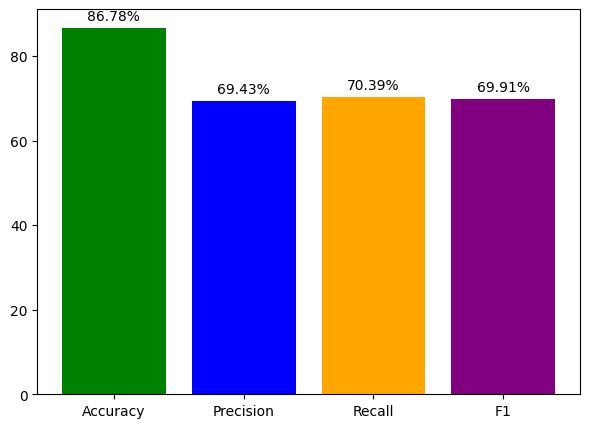

In [30]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
metrics_vals  = [accuracy, precision, recall, f1]
metrics_pct   = [v * 100 for v in metrics_vals]
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics_names, metrics_pct, color=["green", "blue", "orange", "purple"])
for b, v in zip(bars, metrics_pct):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f"{v:.2f}%", ha="center", va="bottom", fontsize=10)
plt.show()

**Plotting Feature Distributions**

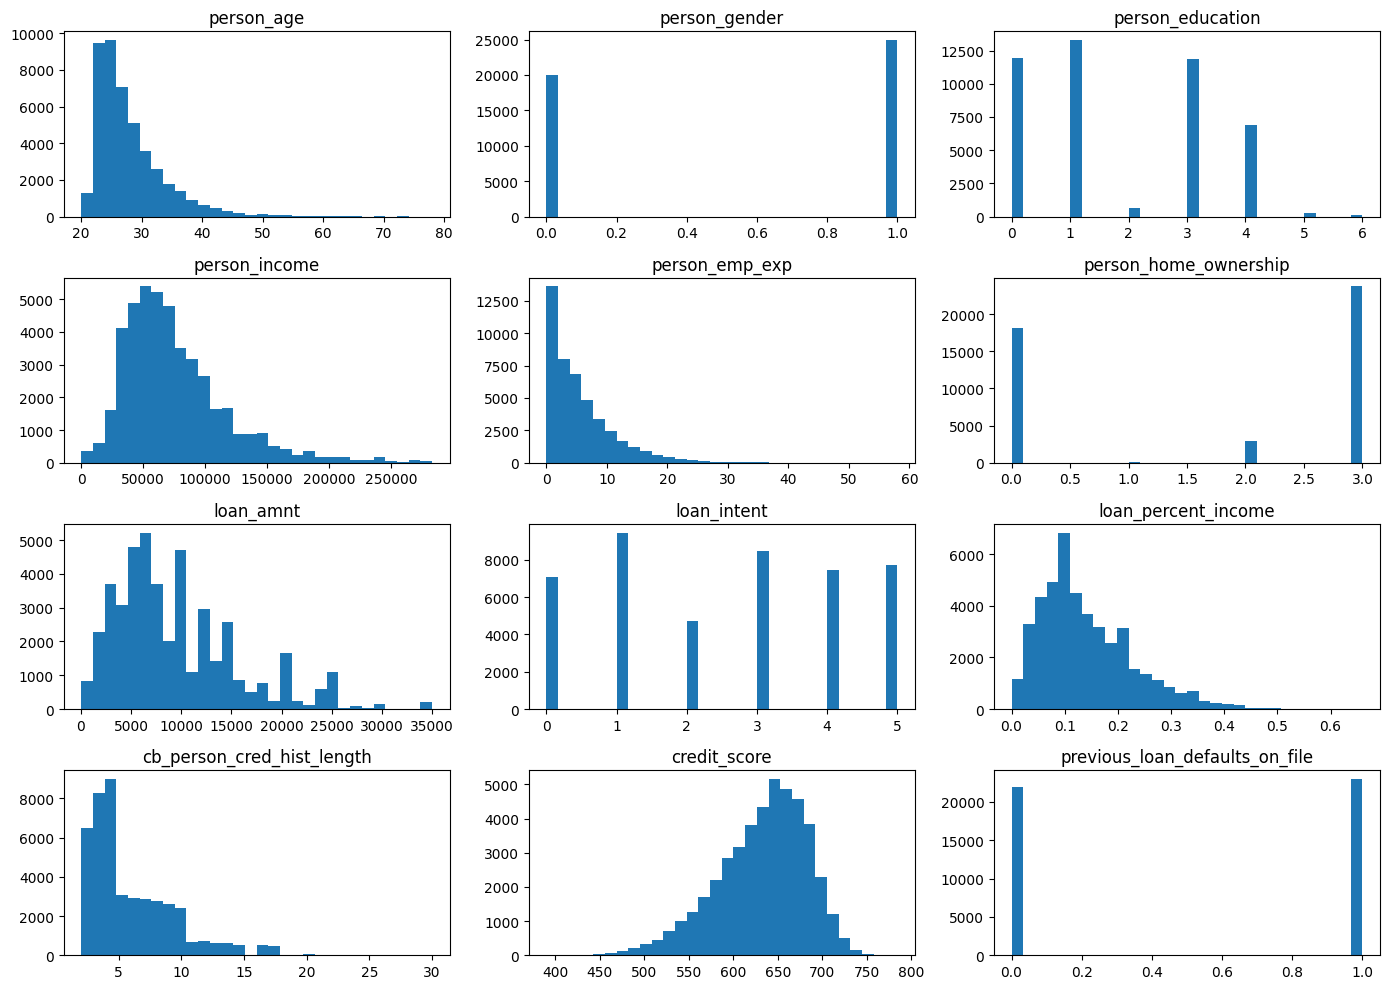

In [31]:
ax = df[num_cols].hist(bins=30, figsize=(14, 10), grid=False)
plt.tight_layout()
plt.show()

**Feature Correlation Map**

<Axes: >

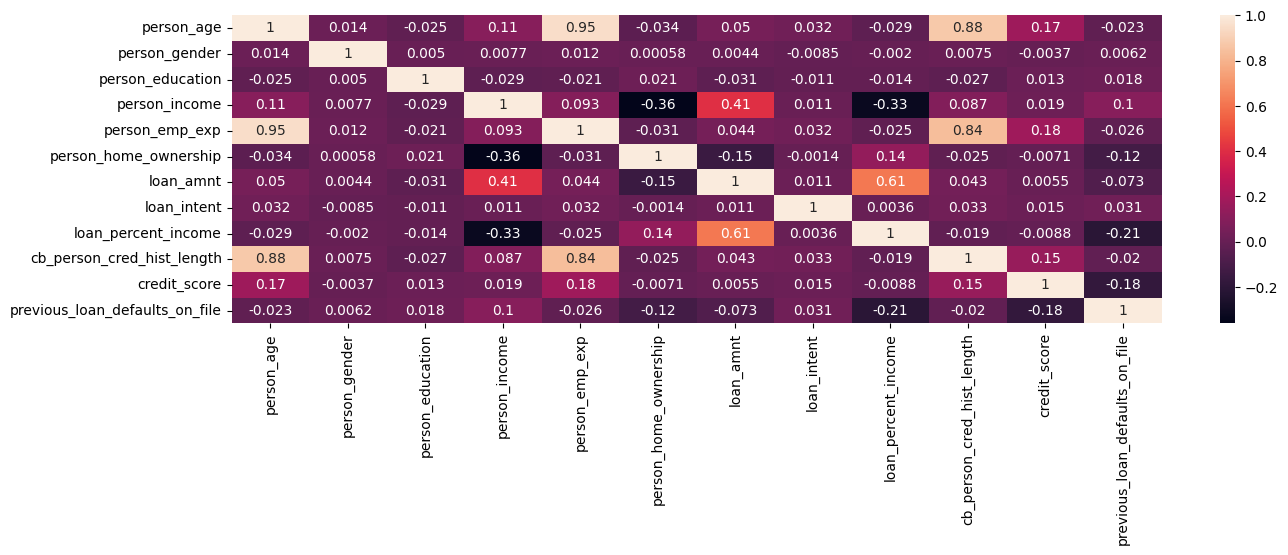

In [32]:
import seaborn as sns
plt.figure(figsize=(15,4))
sns.heatmap(x_train.corr(), annot=True)

**Plotting the decision tree**

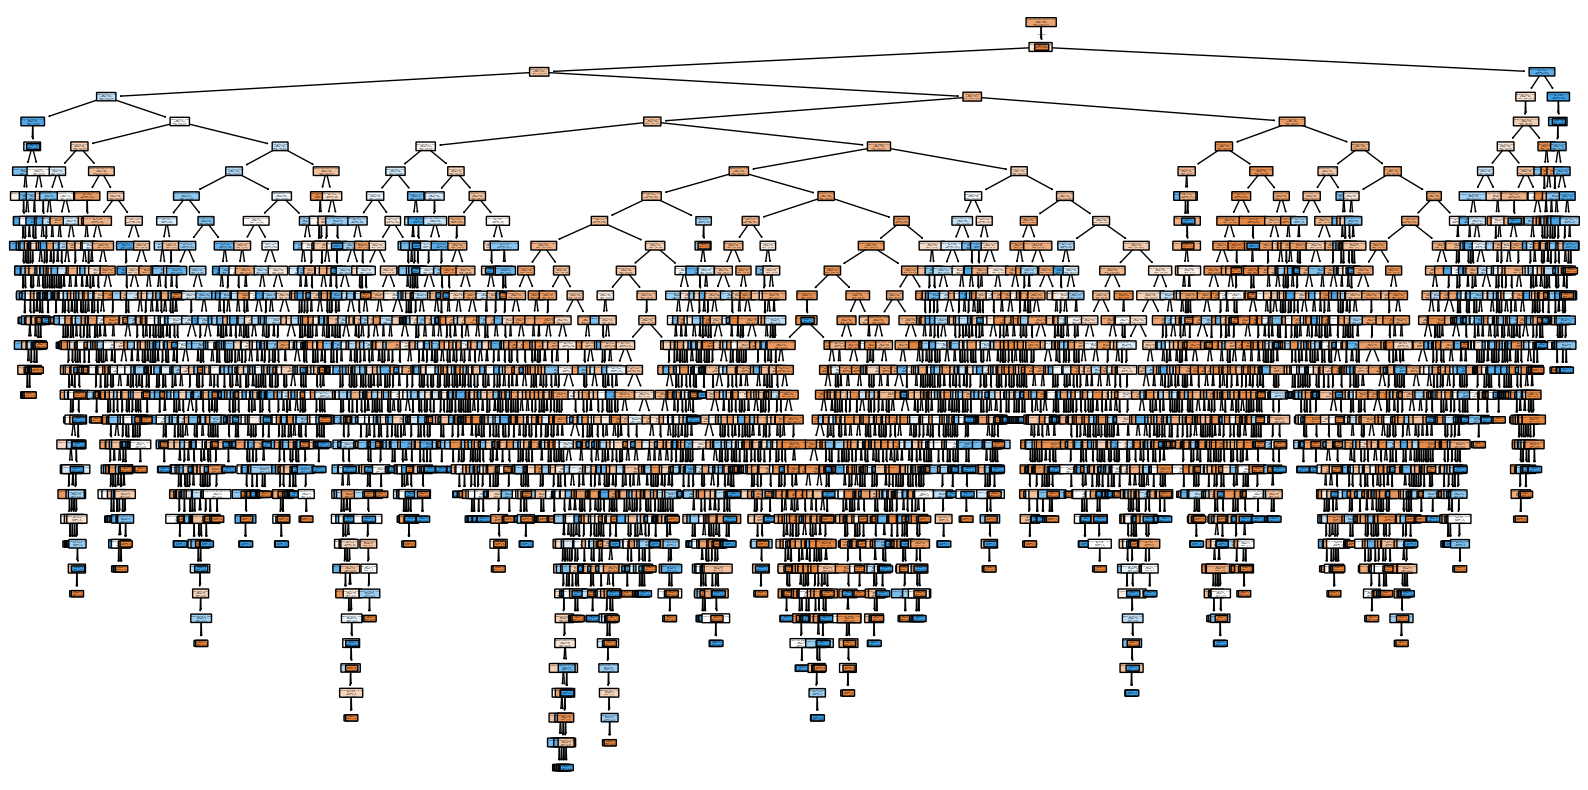

In [33]:
plt.figure(figsize=(20,10))
tree.plot_tree(dtree, filled=True, feature_names=x.columns, class_names=["rejected", "approved"], rounded=True)
plt.show()

**Data Quality Report**

**installing evidently library**

In [34]:
%pip uninstall -y evidently numpy
%pip install --no-cache-dir numpy==1.26.4 evidently==0.4.25

Found existing installation: evidently 0.4.25
Uninstalling evidently-0.4.25:
  Successfully uninstalled evidently-0.4.25
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.

In [35]:
from evidently.report import Report #Library for generating reports
from evidently.metric_preset import DataQualityPreset #Library for generating reports
import evidently, sys #Library for generating reports
import pandas as pd

In [36]:
dirty = pd.read_csv("/content/drive/MyDrive/ai/dirty_data.csv")
clean = pd.read_csv("/content/drive/MyDrive/ai/clean_data.csv")
quality_report = Report(metrics=[DataQualityPreset()])
quality_report.run(reference_data=dirty, current_data=clean)
quality_report.save_html("/content/drive/MyDrive/ai/report_quality_clean.html")
print("Data Quality Report saved successfully")

/tmp/ipython-input-2380762896.py:1: DtypeWarning:

Columns (14,15,16,17,21) have mixed types. Specify dtype option on import or set low_memory=False.



Data Quality Report saved successfully


**Exporting the model as pkl**

In [37]:
joblib.dump(dtree,"/content/drive/MyDrive/ai/loan_approval_v.1.pkl")
from google.colab import files
files.download("/content/drive/MyDrive/ai/loan_approval_v.1.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>